Searching for Pristine Bragg Peak data files (PBP_*.csv)...
Successfully detected 35 energy simulation files.

Running L-BFGS-B optimization engine...

 PARTICLE WEIGHT OPTIMIZATION RESULTS (35 ENERGY LAYERS)
  57854
  60790
  63149
  66455
  70438
  74948
  82037
  90622
 100000
  98295
  74204
  44398
  40986
  48874
  43566
  36673
  36241
  34868
  31794
  31803
  31506
  28514
  27237
  27139
  25478
  25424
  25283
  21584
  21326
  26100
  22510
   9732
   1808
    173
     62



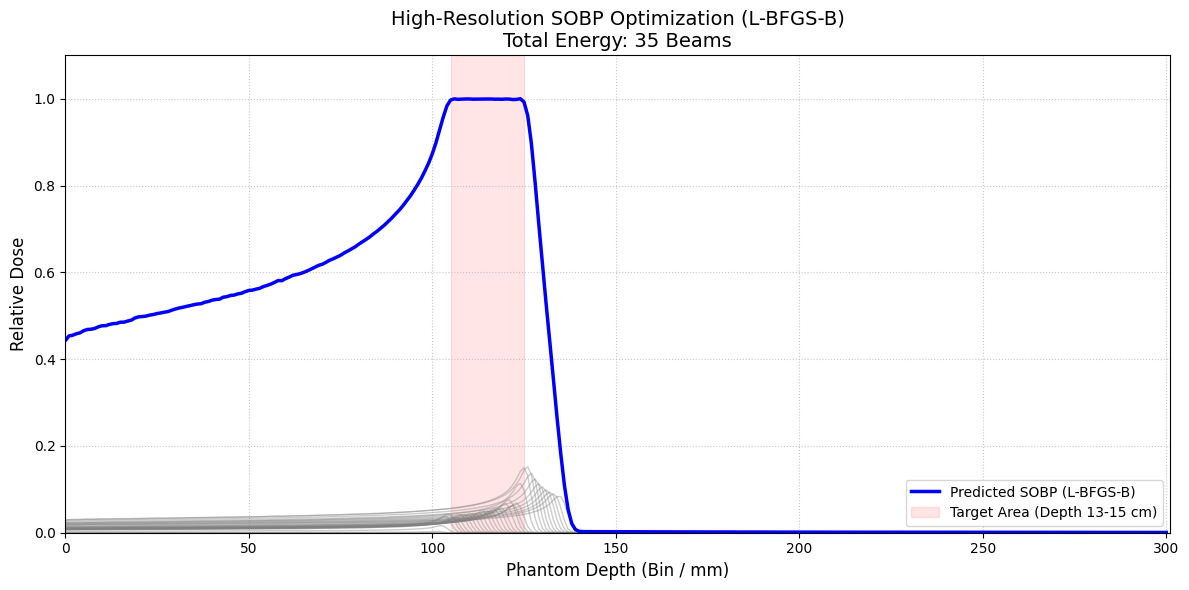

In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import glob
import re

# ==========================================
# 1. TARGET SETTINGS & AUTO-LOAD FILES
# ==========================================
target_start = 105  # Proximal edge of the tumor (Bin 130)
target_end = 125    # Distal edge of the tumor (Bin 150)
max_particles = 1000000000 # Maximum particle scale for TOPAS

print("Searching for Pristine Bragg Peak data files (PBP_*.csv)...")
# Retrieve all files starting with "PBP_" and ending with ".csv" in the same folder
raw_file_list = glob.glob("PBP_*.csv")

# Smart function to extract the energy number from the filename and sort it
def get_energy(file_name):
    number = re.findall(r"\d+\.\d+|\d+", file_name)
    return float(number[0]) if number else 0.0

# Sort files from the highest energy (deepest) to the lowest
file_list = sorted(raw_file_list, key=get_energy, reverse=True)

if not file_list:
    print("ERROR: No PBP_*.csv files found in this folder!")
else:
    print(f"Successfully detected {len(file_list)} energy simulation files.")

# ==========================================
# 2. DATA EXTRACTION & MATRIX CONSTRUCTION
# ==========================================
dose_matrix = []
for file in file_list:
    # Read CSV, ignore TOPAS header, extract the rightmost column
    df = pd.read_csv(file, comment='#', header=None)
    dose_array = df.iloc[:, -1].values
    dose_matrix.append(dose_array)

# Standardize the number of bins (truncate if any file has a longer bin length)
min_len = min(len(arr) for arr in dose_matrix)
dose_matrix_cropped = [arr[:min_len] for arr in dose_matrix]
D = np.column_stack(dose_matrix_cropped)

# MATRIX NORMALIZATION (Key to prevent L-BFGS-B from stalling)
D_max = np.max(D)
D_norm = D / D_max

# Create SOBP Target Line (Dose is set to 1.0 in the tumor area)
t = np.zeros(min_len)
t[target_start:target_end + 1] = 1.0

# ==========================================
# 3. CUSTOM LOSS FUNCTION (L-BFGS-B)
# ==========================================
def loss_function(w, D_mat, target):
    prediction = D_mat.dot(w)
    
    tumor_area_dose = prediction[target_start:target_end+1]
    tumor_area_target = target[target_start:target_end+1]
    
    base_error = (tumor_area_dose - tumor_area_target)**2
    penalty_error = np.where(tumor_area_dose > tumor_area_target, base_error * 10.0, base_error)
    
    # Combine with L2 penalty from the old code
    smoothness_penalty = 0.001 * np.sum(w**2)
    
    return np.mean(penalty_error) + smoothness_penalty

# ==========================================
# 4. TPS OPTIMIZATION EXECUTION (L-BFGS-B)
# ==========================================
print("\nRunning L-BFGS-B optimization engine...")
# Initial guess is set to 0.1 relative particles
w0 = np.ones(D_norm.shape[1]) * 0.1 

# Weights cannot be negative
bounds = [(0, None) for _ in range(D_norm.shape[1])]
result = minimize(loss_function, w0, args=(D_norm, t), method='L-BFGS-B', bounds=bounds)

best_w = result.x

# ==========================================
# 5. CONVERSION TO TOPAS PARTICLE COUNT
# ==========================================
max_w = np.max(best_w)
if max_w > 0:
    particle_weights = np.round((best_w / max_w) * max_particles).astype(int)
else:
    particle_weights = np.zeros(len(best_w), dtype=int)

# ==========================================
# 6. FINAL SOBP VISUALIZATION
# ==========================================
SOBP_prediction_norm = D_norm.dot(best_w)
max_dose_pred = np.max(SOBP_prediction_norm)

# Final plot scale adjusted so the dose peak is exactly at 1.0 (Relative)
SOBP_plot = SOBP_prediction_norm / max_dose_pred
D_plot = D_norm / max_dose_pred
depth_mm = np.arange(min_len)

plt.figure(figsize=(12, 6))

# Plot individual Pristine Beam curves
for i in range(len(best_w)):
    if best_w[i] > 0:
        plt.plot(depth_mm, D_plot[:, i] * best_w[i], color='gray', alpha=0.4, linewidth=1.0)

print(f"\n{'='*65}")
print(f" PARTICLE WEIGHT OPTIMIZATION RESULTS ({len(file_list)} ENERGY LAYERS)")
print(f"{'='*65}")
for i, weight in enumerate(particle_weights):
    print(f"{weight:7d}")
print(f"{'='*65}\n")

# Plot Combined SOBP Curve
plt.plot(depth_mm, SOBP_plot, 'b-', linewidth=2.5, label='Predicted SOBP (L-BFGS-B)')

# Highlight Target Tumor Area
plt.axvspan(target_start, target_end, color='red', alpha=0.1, label='Target Area (Depth 13-15 cm)')

plt.title(f'High-Resolution SOBP Optimization (L-BFGS-B)\nTotal Energy: {len(file_list)} Beams', fontsize=14)
plt.xlabel('Phantom Depth (Bin / mm)', fontsize=12)
plt.ylabel('Relative Dose', fontsize=12)
plt.xlim([0, min_len])
plt.ylim([0, 1.1])
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()